# Combined mobility flows – average full day (Motorized + VBZ + Ped + Bike)

Goal:
- Aggregate each source into a *single* “full-day” flow per segment:
  - Motorized traffic: sum over hours (already day profile)
  - VBZ: sum over hours (already day profile)
  - Ped/Bike: sum over hours per date, then mean across dates per segment
- Plot on an interactive OSM basemap with toggleable layers.


## Imports

In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np

import folium
from folium import FeatureGroup
from folium.features import GeoJson, GeoJsonTooltip

import branca.colormap as cm


## Paths

In [5]:
# Motorized (GeoParquet, hourly by segment)
MOTORIZED_PATH = "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/motorized_traffic/2025/2025_motorized_traffic_complete_full.parquet"

# Public transport VBZ (GeoParquet, hourly by segment)
VBZ_PATH = "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/vbz_flows/V1_vbz_flows_hourly.parquet"

# Ped/Bike (edges + flows)
PED_EDGES_PATH = "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/zurich_pedbike_flows/2025/ped_edges.parquet"
PED_FLOWS_PATH = "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/zurich_pedbike_flows/2025/ped_flows.parquet"

BIKE_EDGES_PATH = "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/zurich_pedbike_flows/2025/bike_edges.parquet"
BIKE_FLOWS_PATH = "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/zurich_pedbike_flows/2025/bike_flows.parquet"


## Load & aggregate Motorized (full day)

In [6]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def find_flow_col(df):
    # Prefer columns that include 'flow' but not 'norm'
    flow_like = [c for c in df.columns if "flow" in c.lower() and "norm" not in c.lower()]
    # If multiple, pick the first
    return flow_like[0] if flow_like else None

def ensure_4326(gdf):
    if gdf.crs is None:
        raise ValueError("GeoDataFrame CRS is None. Set CRS before mapping.")
    return gdf.to_crs(epsg=4326)

def make_edge_id_from_uvk(df, u="u", v="v", k="key", out="edge_id"):
    df[out] = df[u].astype(str) + "_" + df[v].astype(str) + "_" + df[k].astype(str)
    return df

def aggregate_hourly_to_daily_sum(gdf, hour_col, flow_col, group_cols):
    # daily sum across hours (no date dimension here)
    out = gdf.groupby(group_cols, as_index=False)[flow_col].sum()
    return out

def aggregate_flows_avg_day_per_edge(flows_df, date_col, hour_col, flow_col, edge_id_col):
    """
    1) Sum hours within each DATE × edge
    2) Mean across dates per edge => "average full day"
    """
    flows_df = flows_df.copy()
    flows_df[date_col] = pd.to_datetime(flows_df[date_col])

    daily = flows_df.groupby([date_col, edge_id_col], as_index=False)[flow_col].sum()
    avg_day = daily.groupby(edge_id_col, as_index=False)[flow_col].mean()
    return avg_day


## Load & aggregate Motorized (full day)

In [7]:
motor_gdf = gpd.read_parquet(MOTORIZED_PATH)
print("Motorized cols:", list(motor_gdf.columns))

# Auto-detect columns (override if needed)
MOTOR_HOUR_COL = pick_col(motor_gdf, ["hour", "HOUR"])
MOTOR_FLOW_COL = find_flow_col(motor_gdf)  # e.g. "flow", "traffic_flow", ...
MOTOR_EDGE_ID_COL = pick_col(motor_gdf, ["edge_id"])  # if exists

print("Detected:", MOTOR_HOUR_COL, MOTOR_FLOW_COL, MOTOR_EDGE_ID_COL)

if MOTOR_FLOW_COL is None:
    raise ValueError("Could not auto-detect motorized flow column. Set MOTOR_FLOW_COL manually.")

# Grouping key: prefer edge_id, else u/v/key if present, else geometry
if MOTOR_EDGE_ID_COL is not None:
    group_cols = [MOTOR_EDGE_ID_COL, "geometry"]
elif all(c in motor_gdf.columns for c in ["u", "v", "key"]):
    motor_gdf = make_edge_id_from_uvk(motor_gdf, "u", "v", "key", "edge_id")
    group_cols = ["edge_id", "geometry"]
else:
    group_cols = ["geometry"]

motor_day = aggregate_hourly_to_daily_sum(
    motor_gdf,
    hour_col=MOTOR_HOUR_COL,
    flow_col=MOTOR_FLOW_COL,
    group_cols=group_cols
)

motor_day_gdf = gpd.GeoDataFrame(motor_day, geometry="geometry", crs=motor_gdf.crs)
motor_day_gdf = motor_day_gdf.rename(columns={MOTOR_FLOW_COL: "flow_day"})
motor_day_gdf["mode"] = "motorized"

print("Motorized daily segments:", motor_day_gdf.shape)
motor_day_gdf.head()


Motorized cols: ['u', 'v', 'key', 'hour', 'total_flow', 'n_sources', 'name', 'length', 'bearing', 'geometry', 'flow_norm']
Detected: hour total_flow None
Motorized daily segments: (3663, 4)


,edge_id,geometry,flow_day,mode
0,10066996012_3250568442_0,"LINESTRING (2682888.197 1247561.479, 2682891.2...",2852.822946,motorized
1,10066996012_34505894_0,"LINESTRING (2682888.197 1247561.479, 2682890.9...",4918.343685,motorized
2,10206960759_30826180_0,"LINESTRING (2681844.092 1247795.439, 2681855.2...",3433.019697,motorized
3,10228354152_279263018_0,"LINESTRING (2682208.72 1247928.113, 2682220.01...",2475.550552,motorized
4,10228354152_28137450_0,"LINESTRING (2682208.72 1247928.113, 2682174.18...",2652.038485,motorized


## Load & aggregate Ped (average full day across all dates)

In [8]:
vbz_gdf = gpd.read_parquet(VBZ_PATH)
print("VBZ cols:", list(vbz_gdf.columns))

# Known from your schema
VBZ_HOUR_COL = "hour"
VBZ_FLOW_COL = "flow_besetzung"

vbz = vbz_gdf.copy()
vbz[VBZ_HOUR_COL] = vbz[VBZ_HOUR_COL].astype(int)

# Define segment id
vbz["edge_id"] = vbz["Haltestellen_Id"].astype(str) + "_" + vbz["Nach_Hst_Id"].astype(str)

vbz_day = vbz.groupby(["edge_id", "geometry"], as_index=False)[VBZ_FLOW_COL].sum()
vbz_day_gdf = gpd.GeoDataFrame(vbz_day, geometry="geometry", crs=vbz_gdf.crs)
vbz_day_gdf = vbz_day_gdf.rename(columns={VBZ_FLOW_COL: "flow_day"})
vbz_day_gdf["mode"] = "vbz"

print("VBZ daily segments:", vbz_day_gdf.shape)
vbz_day_gdf.head()


VBZ cols: ['Haltestellen_Id', 'Nach_Hst_Id', 'hour', 'flow_besetzung', 'n_runs', 'geometry']
VBZ daily segments: (1555, 4)


,edge_id,geometry,flow_day,mode
0,100_101,"LINESTRING (2679141.928 1249299.905, 2679232.0...",7280.00118,vbz
1,100_154,"LINESTRING (2679141.928 1249299.905, 2679135.8...",24809.04465,vbz
2,100_99,"LINESTRING (2679141.928 1249299.905, 2679186.8...",26563.53324,vbz
3,101_100,"LINESTRING (2679375.036 1249180.523, 2679304.4...",3984.38200,vbz
4,101_102,"LINESTRING (2679375.036 1249180.523, 2679461.8...",7425.33618,vbz


## Load & aggregate Bike (average full day across all dates)

In [9]:
ped_edges = gpd.read_parquet(PED_EDGES_PATH)
ped_flows = pd.read_parquet(PED_FLOWS_PATH)

# Edge ids (u,v,key) match your stored flows
ped_edges = make_edge_id_from_uvk(ped_edges, "u", "v", "key", "edge_id")
ped_flows = make_edge_id_from_uvk(ped_flows, "u", "v", "key", "edge_id")

PED_DATE_COL = "DATE"
PED_HOUR_COL = "HOUR"
PED_FLOW_COL = "ped_flow"  # or use "ped_flow_norm" if you prefer

ped_avg = aggregate_flows_avg_day_per_edge(
    ped_flows,
    date_col=PED_DATE_COL,
    hour_col=PED_HOUR_COL,
    flow_col=PED_FLOW_COL,
    edge_id_col="edge_id",
)

ped_day_gdf = ped_edges.merge(ped_avg, on="edge_id", how="left")
ped_day_gdf[PED_FLOW_COL] = ped_day_gdf[PED_FLOW_COL].fillna(0.0)

ped_day_gdf = ped_day_gdf.rename(columns={PED_FLOW_COL: "flow_day"})
ped_day_gdf["mode"] = "pedestrian"

print("Ped avg-day segments:", ped_day_gdf.shape)
ped_day_gdf.head()


Ped avg-day segments: (201822, 27)


,u,v,key,osmid,oneway,lanes,name,highway,maxspeed,reversed,...,bridge,access,width,junction,tunnel,est_width,area,edge_id,flow_day,mode
0,453805,3780703398,0,172063131,False,3,Hohlstrasse,tertiary,50,False,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_3780703398_0,0.0,pedestrian
1,453805,3780703400,0,374688190,False,3,Hohlstrasse,tertiary,50,True,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_3780703400_0,0.0,pedestrian
2,453805,3780703401,0,5880367,False,4,Duttweilerbrücke,tertiary,50,True,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_3780703401_0,0.0,pedestrian
3,453805,5730016968,0,521343968,False,2,Herdernstrasse,tertiary,50,False,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_5730016968_0,0.0,pedestrian
4,453810,3835970610,0,23167513,False,<NA>,Herdernstrasse,tertiary,30,False,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453810_3835970610_0,0.0,pedestrian


## Cell Load & aggregate Bike (average full day across all dates)

In [10]:
bike_edges = gpd.read_parquet(BIKE_EDGES_PATH)
bike_flows = pd.read_parquet(BIKE_FLOWS_PATH)

bike_edges = make_edge_id_from_uvk(bike_edges, "u", "v", "key", "edge_id")
bike_flows = make_edge_id_from_uvk(bike_flows, "u", "v", "key", "edge_id")

BIKE_DATE_COL = "DATE"
BIKE_HOUR_COL = "HOUR"
BIKE_FLOW_COL = "bike_flow"  # or "bike_flow_norm" if present

bike_avg = aggregate_flows_avg_day_per_edge(
    bike_flows,
    date_col=BIKE_DATE_COL,
    hour_col=BIKE_HOUR_COL,
    flow_col=BIKE_FLOW_COL,
    edge_id_col="edge_id",
)

bike_day_gdf = bike_edges.merge(bike_avg, on="edge_id", how="left")
bike_day_gdf[BIKE_FLOW_COL] = bike_day_gdf[BIKE_FLOW_COL].fillna(0.0)

bike_day_gdf = bike_day_gdf.rename(columns={BIKE_FLOW_COL: "flow_day"})
bike_day_gdf["mode"] = "bike"

print("Bike avg-day segments:", bike_day_gdf.shape)
bike_day_gdf.head()


Bike avg-day segments: (44639, 27)


,u,v,key,osmid,lanes,name,highway,maxspeed,oneway,reversed,...,tunnel,ref,access,width,junction,est_width,area,edge_id,flow_day,mode
0,453801,1990946417,0,1007827872,4,Duttweilerbrücke,tertiary,50,False,False,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453801_1990946417_0,0.0,bike
1,453801,1229170106,0,5880366,2,Duttweilerbrücke,tertiary,50,False,True,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453801_1229170106_0,0.0,bike
2,453805,1990946417,0,5880367,4,Duttweilerbrücke,tertiary,50,False,True,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_1990946417_0,0.0,bike
3,453805,5132952919,0,172063131,3,Hohlstrasse,tertiary,50,False,False,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_5132952919_0,0.0,bike
4,453805,74574330,0,"[374688188, 603655389, 374688190]",3,Hohlstrasse,tertiary,50,False,True,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_74574330_0,0.0,bike


## ## Load & aggregate Motorized (full day)

In [11]:
def add_flow_layer(
    fmap,
    gdf,
    layer_name,
    color,
    weight_min=1,
    weight_max=6,
    quantile_clip=(0.02, 0.98),
    tooltip_fields=("mode", "flow_day")
):
    """
    Adds a GeoJSON layer with line weight scaled by flow_day.
    Uses a single color per mode (clean) and width encoding (strong).
    """
    gdf = gdf.copy()
    gdf = ensure_4326(gdf)

    # clip extremes so one crazy segment doesn't flatten everything
    lo = gdf["flow_day"].quantile(quantile_clip[0])
    hi = gdf["flow_day"].quantile(quantile_clip[1])
    denom = max(hi - lo, 1e-9)

    def style_fn(feature):
        v = feature["properties"].get("flow_day", 0.0) or 0.0
        v_clip = min(max(v, lo), hi)
        w = weight_min + (weight_max - weight_min) * ((v_clip - lo) / denom)
        return {
            "color": color,
            "weight": float(w),
            "opacity": 0.75,
        }

    gj = GeoJson(
        gdf,
        name=layer_name,
        style_function=style_fn,
        tooltip=GeoJsonTooltip(fields=list(tooltip_fields)),
    )
    gj.add_to(fmap)

    return fmap


## Build Map

In [12]:
# Reproject everything to 4326 for folium bounds/centering
motor_4326 = ensure_4326(motor_day_gdf)
vbz_4326   = ensure_4326(vbz_day_gdf)
ped_4326   = ensure_4326(ped_day_gdf)
bike_4326  = ensure_4326(bike_day_gdf)

# Compute a map center from all geometries
all_bounds = np.vstack([
    motor_4326.total_bounds,
    vbz_4326.total_bounds,
    ped_4326.total_bounds,
    bike_4326.total_bounds,
])
minx, miny = all_bounds[:, 0].min(), all_bounds[:, 1].min()
maxx, maxy = all_bounds[:, 2].max(), all_bounds[:, 3].max()
center = [(miny + maxy) / 2, (minx + maxx) / 2]

m = folium.Map(location=center, zoom_start=13, tiles="OpenStreetMap", control_scale=True)

# Add layers (each as a toggle)
add_flow_layer(m, motor_4326, layer_name="Motorized traffic (full day)", color="#e41a1c", tooltip_fields=("mode","flow_day"))
add_flow_layer(m, vbz_4326,   layer_name="Public transport VBZ (full day)", color="#377eb8", tooltip_fields=("mode","flow_day"))
add_flow_layer(m, ped_4326,   layer_name="Pedestrian (avg full day)", color="#4daf4a", tooltip_fields=("mode","flow_day"))
add_flow_layer(m, bike_4326,  layer_name="Bike (avg full day)", color="#ff7f00", tooltip_fields=("mode","flow_day"))

folium.LayerControl(collapsed=False).add_to(m)

m


KeyboardInterrupt: 

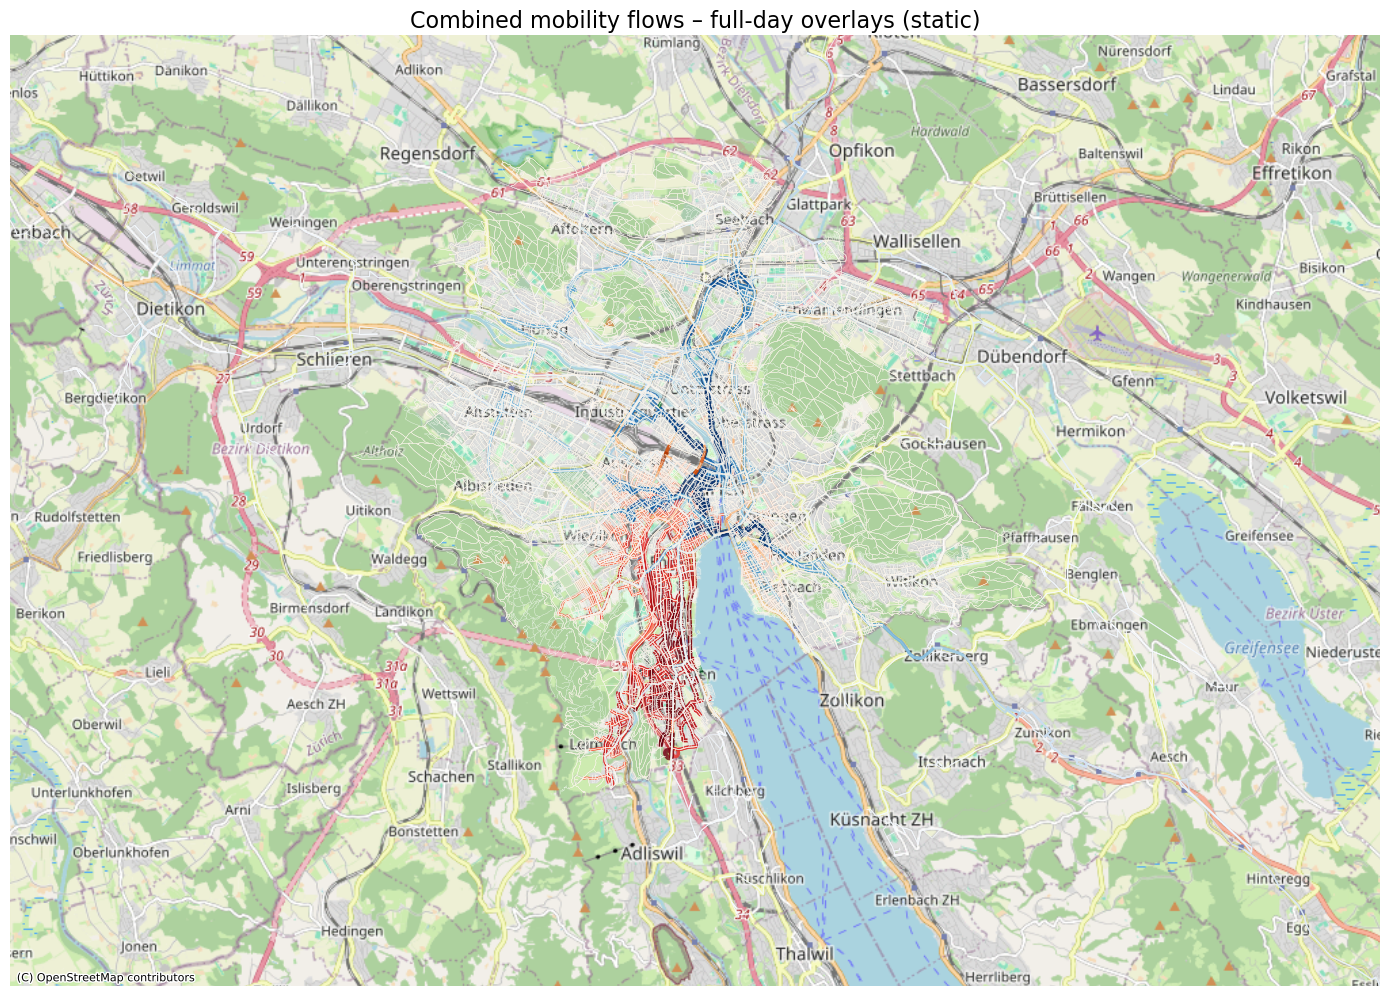

In [13]:
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np

# -----------------------------
# Layer toggles (turn on/off)
# -----------------------------
SHOW_MOTORIZED = True
SHOW_VBZ       = True
SHOW_PED       = True
SHOW_BIKE      = True

# -----------------------------
# Styling controls per layer
# (separate scales; otherwise one mode dominates)
# -----------------------------
LAYER_STYLE = {
    "motorized": {"cmap": plt.cm.Reds,    "base_lw": 0.3, "max_extra_lw": 3.0, "alpha": 0.75},
    "vbz":       {"cmap": plt.cm.Blues,   "base_lw": 0.6, "max_extra_lw": 3.5, "alpha": 0.80},
    "ped":       {"cmap": plt.cm.Greens,  "base_lw": 0.2, "max_extra_lw": 2.5, "alpha": 0.70},
    "bike":      {"cmap": plt.cm.Oranges, "base_lw": 0.3, "max_extra_lw": 3.0, "alpha": 0.75},
}

# Quantile clipping for robust scaling (helps avoid one extreme segment dominating)
Q_LO, Q_HI = 0.02, 0.98

def prepare_layer(gdf, mode_name):
    """Reproject to 3857, compute per-layer norm range (quantile-clipped)."""
    g = gdf.copy().to_crs(epsg=3857)
    vals = g["flow_day"].astype(float).values

    lo = np.nanquantile(vals, Q_LO)
    hi = np.nanquantile(vals, Q_HI)
    if hi <= lo:
        hi = max(lo + 1e-9, np.nanmax(vals))

    norm = Normalize(vmin=lo, vmax=hi)
    return g, norm

def plot_layer(ax, gdf_3857, norm, style):
    """Plot one layer with width+color encoding."""
    vals = gdf_3857["flow_day"].astype(float).values
    colors = style["cmap"](norm(vals))

    lw = style["base_lw"] + style["max_extra_lw"] * (
        np.clip((vals - norm.vmin) / max(norm.vmax - norm.vmin, 1e-9), 0, 1)
    )

    gdf_3857.plot(
        ax=ax,
        color=colors,
        linewidth=lw,
        alpha=style["alpha"],
        zorder=2,
    )

# -----------------------------
# Prepare layers (3857 + norms)
# -----------------------------
layers = []

if SHOW_MOTORIZED:
    g, n = prepare_layer(motor_day_gdf, "motorized")
    layers.append(("Motorized traffic", "motorized", g, n))

if SHOW_VBZ:
    g, n = prepare_layer(vbz_day_gdf, "vbz")
    layers.append(("VBZ public transport", "vbz", g, n))

if SHOW_PED:
    g, n = prepare_layer(ped_day_gdf, "ped")
    layers.append(("Pedestrian", "ped", g, n))

if SHOW_BIKE:
    g, n = prepare_layer(bike_day_gdf, "bike")
    layers.append(("Bike", "bike", g, n))

if not layers:
    raise ValueError("All layers are disabled. Set at least one SHOW_* = True.")

# -----------------------------
# Determine common extent
# -----------------------------
all_bounds = np.array([lay[2].total_bounds for lay in layers])  # (minx,miny,maxx,maxy)
minx, miny = all_bounds[:, 0].min(), all_bounds[:, 1].min()
maxx, maxy = all_bounds[:, 2].max(), all_bounds[:, 3].max()

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Basemap first (zorder=1)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    crs="EPSG:3857",
    zorder=1,
)

# Then plot each layer (zorder=2)
for title, mode_key, gdf_3857, norm in layers:
    plot_layer(ax, gdf_3857, norm, LAYER_STYLE[mode_key])

ax.set_axis_off()
ax.set_title("Combined mobility flows – full-day overlays (static)", fontsize=16)
plt.tight_layout()
plt.show()
